In [1]:
import os
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

### Analyzing Corpus

In [2]:
nltk.download('punkt')

# Define the directory containing the corpus files
corpus_dir = "storage/corpus/"

# Initialize containers to hold results
document_stats = []

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/nainireddy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
# Process each file in the corpus directory
for filename in os.listdir(corpus_dir):
    if filename.endswith(".txt.clean"):
        file_path = os.path.join(corpus_dir, filename)
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()
            sentences = sent_tokenize(text)
            words = word_tokenize(text.lower())
            
            # Basic stats
            num_sentences = len(sentences)
            num_words = len(words)
            avg_sentence_length = num_words / num_sentences
            word_freq = Counter(words)
            
            document_stats.append({
                "filename": filename,
                "num_sentences": num_sentences,
                "num_words": num_words,
                "avg_sentence_length": avg_sentence_length,
                "top_5_words": word_freq.most_common(5)
            })


In [4]:
# Display the stats for each document
for stat in document_stats:
    print(f"Document: {stat['filename']}")
    print(f" - Number of sentences: {stat['num_sentences']}")
    print(f" - Number of words: {stat['num_words']}")
    print(f" - Average sentence length: {stat['avg_sentence_length']:.2f} words")
    print(f" - Top 5 most frequent words: {stat['top_5_words']}")
    print()

Document: S08_set3_a6.txt.clean
 - Number of sentences: 155
 - Number of words: 3821
 - Average sentence length: 24.65 words
 - Top 5 most frequent words: [('the', 244), (',', 208), ('.', 133), ('of', 125), ('cleveland', 95)]

Document: S08_set3_a10.txt.clean
 - Number of sentences: 441
 - Number of words: 10542
 - Average sentence length: 23.90 words
 - Top 5 most frequent words: [(',', 660), ('the', 606), ('.', 372), ('ford', 264), ('of', 260)]

Document: S08_set3_a1.txt.clean
 - Number of sentences: 292
 - Number of words: 7283
 - Average sentence length: 24.94 words
 - Top 5 most frequent words: [('the', 463), (',', 409), ('of', 272), ('.', 266), ('and', 196)]

Document: S08_set3_a7.txt.clean
 - Number of sentences: 567
 - Number of words: 13718
 - Average sentence length: 24.19 words
 - Top 5 most frequent words: [('the', 844), (',', 820), ('.', 510), ('of', 385), ('and', 356)]

Document: S08_set3_a2.txt.clean
 - Number of sentences: 77
 - Number of words: 1752
 - Average sentence

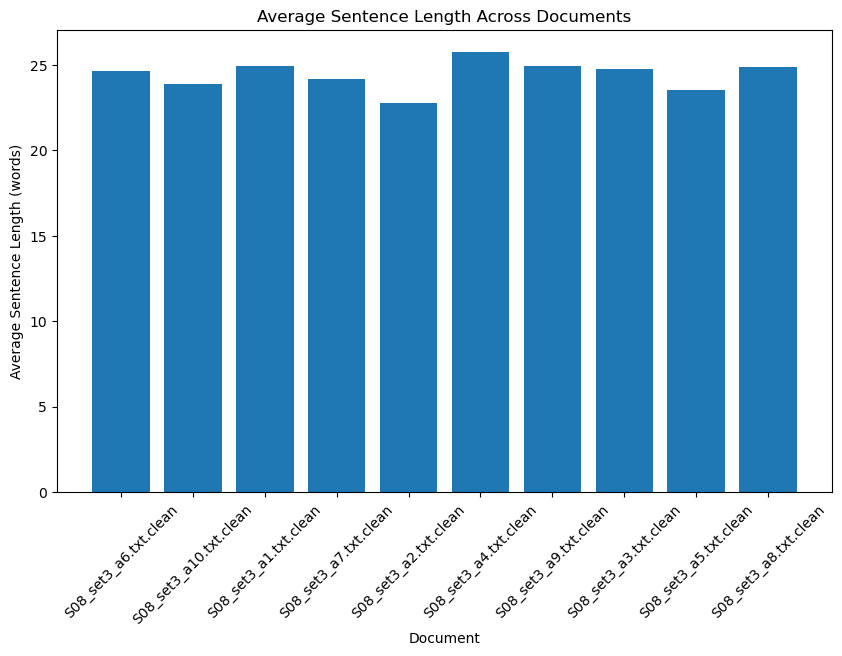

In [5]:
# Plot distribution of sentence lengths across documents
avg_lengths = [stat['avg_sentence_length'] for stat in document_stats]
plt.figure(figsize=(10, 6))
plt.bar([stat['filename'] for stat in document_stats], avg_lengths)
plt.xlabel('Document')
plt.ylabel('Average Sentence Length (words)')
plt.title('Average Sentence Length Across Documents')
plt.xticks(rotation=45)
plt.show()

### Analyzing Questions

In [8]:
# Load the questions CSV file
questions_df = pd.read_csv("qa_resources/questions.csv", delimiter="\t")

# Basic statistics on question difficulty
difficulty_questioner = questions_df['DifficultyFromQuestioner'].value_counts()
difficulty_answerer = questions_df['DifficultyFromAnswerer'].value_counts()

In [9]:
# Display the difficulty distributions
print("Difficulty Distribution from Questioner:")
print(difficulty_questioner)
print("\nDifficulty Distribution from Answerer:")
print(difficulty_answerer)

Difficulty Distribution from Questioner:
DifficultyFromQuestioner
easy      33
medium    33
hard      32
Name: count, dtype: int64

Difficulty Distribution from Answerer:
DifficultyFromAnswerer
easy        41
medium      31
hard        15
too hard     4
Name: count, dtype: int64


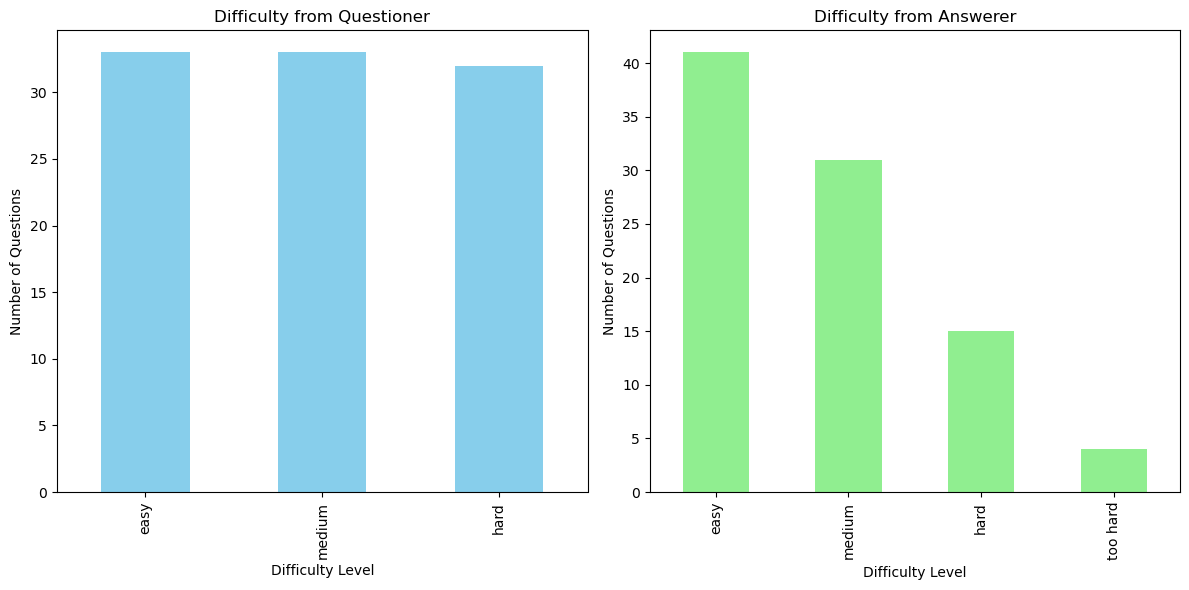

In [10]:
# Plot difficulty distributions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
difficulty_questioner.plot(kind='bar', color='skyblue')
plt.title('Difficulty from Questioner')
plt.xlabel('Difficulty Level')
plt.ylabel('Number of Questions')

plt.subplot(1, 2, 2)
difficulty_answerer.plot(kind='bar', color='lightgreen')
plt.title('Difficulty from Answerer')
plt.xlabel('Difficulty Level')
plt.ylabel('Number of Questions')

plt.tight_layout()
plt.show()

In [11]:
# Analyze unique questions and their frequencies
unique_questions = questions_df['Question'].value_counts()
print("\nTop 5 Most Frequent Questions:")
print(unique_questions.head())


Top 5 Most Frequent Questions:
Question
How did the supporters of Henry Clay feel about Fillmore in 1848?    3
How did Fillmore ascend to the presidency?                           3
What did Taylor and Fillmore disagree upon?                          3
Who did Millard Fillmore fall in love with?                          3
To whom was Millard Fillmore born to?                                3
Name: count, dtype: int64


### Significant Findings

#### Finding 1: High Frequency of Common Stop Words

In the analysis of the corpus files, we observed that common stop words like "the," "of," "and," and punctuation marks such as commas and periods frequently appear as the top words in all documents. These words are integral to sentence structure but contribute little to the semantic content of the text. For example, in S08_set3_a7.txt.clean, the top five most frequent words are "the" (844 occurrences), "," (820 occurrences), "." (510 occurrences), "of" (385 occurrences), and "and" (356 occurrences).

Stop words typically do not carry significant meaning on their own and are often removed in text processing tasks to reduce noise and improve the focus on meaningful content. However, in this corpus, their overwhelming presence suggests that without proper preprocessing, the embeddings generated from the text might place undue emphasis on these words. This could dilute the quality of the embeddings by causing them to focus on irrelevant aspects of the text, such as grammatical structure, rather than the core content.

Since embeddings capture semantic information, the high frequency of stop words could lead to embeddings that reflect the structure of sentences rather than their content. This could make it harder for the system to distinguish between contexts that are semantically different but structurally similar, thereby reducing the accuracy of retrieval.

In a retrieval-augmented generation system, precision is critical for retrieving the most relevant context for a given query. If embeddings are influenced heavily by stop words, the system might retrieve irrelevant or less relevant contexts that happen to share common structural words with the query, rather than contexts that truly match the query's intent.

It is crucial to implement a stop word removal step in the preprocessing pipeline to ensure that embeddings focus on the content that matters. Alternatively, if stop words are retained, their influence should be minimized, perhaps by applying weighting schemes that reduce their impact on the final embeddings.

#### Finding 2: Variation in Document Length and Sentence Count

The corpus contains documents with significant variation in both the number of sentences and the total word count. For example, S08_set3_a2.txt.clean has only 77 sentences, while S08_set3_a7.txt.clean has 567 sentences. 

This variation presents a challenge when chunking the documents into smaller text segments for embedding generation and subsequent retrieval. Inconsistent chunking, where some documents produce many more chunks than others, can lead to a few potential issues. 

Longer documents that produce more chunks might dominate the retrieval space, leading to a higher likelihood of these documents being retrieved regardless of their actual relevance. This could skew the results and reduce the diversity of contexts retrieved for a query.

When a document is chunked into many small segments, the contextual coherence within each chunk might be diluted. This could result in chunks that lack sufficient context to be meaningfully retrieved, leading to less accurate or less informative results.

Processing and storing a large number of chunks from lengthy documents could increase computational overhead and storage requirements. Additionally, during retrieval, searching through a larger set of chunks could slow down the system.

The variation in document lengths necessitates a careful approach to chunking during preprocessing. If chunks are too small, they may not capture enough context, leading to less relevant retrieval results. Conversely, overly large chunks can blend different contexts, making it difficult to retrieve the most relevant section. To maintain high retrieval accuracy, it's crucial to balance chunk size so that each chunk is informative without being overly specific. Additionally, normalizing the number of chunks per document or scaling the weighting of chunks based on document length can prevent longer documents from disproportionately influencing the retrieval process, ensuring more balanced and accurate results.